## **Homework_2_Multimodal_Fusion_and_Alignment_meme**



[Original notebook](https://colab.research.google.com/drive/1JnpfHAn--kHNbGHbmavowPwqJrX9Ky5y?usp=sharing)

In [19]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler
!pip install transformers==4.40.0 # added

mkdir: cannot create directory ‘data’: File exists


In [ ]:
# import library

import os
import pandas as pd
import numpy as np
import torch
import transformers
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.data import random_split
from transformers import BertTokenizer, BertModel

import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from datasets import load_dataset

# Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
- **Fusion type:** Late fusion might be preferred — meme meaning emerges from the *interaction* between image and text (metaphor, irony). Each modality should encode independently before being combined.
- **Alignment level:** Minimal alignment (shared projection dimension) likely suffices. I believe aggressive semantic alignment may suppress the cross-modal tension that carries meme meaning.

2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
experiment design:
- **Experiment:** Compare (early/late fusion) × (with/without contrastive pre-alignment) on validation accuracy to isolate each factor.
- **Challenge:** Meme text often deliberately contradicts the image — I suspect this makes contrastive alignment particularly noisy, since the "positive pair" signal is weak.


3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
[not sure]
- **Implication:** Large models may converge to a shared representation of reality across modalities — plausible for standard vision-language tasks.
- I am skeptical this holds for memes: their semantics are grounded in internet culture and irony, not the physical world that general-purpose scaling captures.


4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
- **Modality bias persists:** Vision and language capture structurally different aspects of the world; I suspect these biases remain even at scale.
- **Domain gap:** Memes are a niche distribution — alignment may not emerge without in-domain training data.
- **Partial evidence:** Probing studies suggest vision-only and language-only representations retain systematic differences (Huh et al., 2024 acknowledges this as a limitation).

5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
- **CKA across scales:** Measure Centered Kernel Alignment between image/text encoders as model size grows — emergent alignment would show rising scores.
- **Zero-shot retrieval:** Image-to-text retrieval accuracy on held-out memes without contrastive fine-tuning; improvement with scale suggests emergent alignment.

6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?
- **Risk:** Perfect alignment likely collapses the cross-modal dissonance that encodes meme sarcasm and metaphor.
- **Probing test:** Probe aligned image encoder for visual-only features — accuracy drop indicates modality-specific information loss.
- **Ablation:** Sweep λ ∈ {0, 0.1, 0.5, 1.0} for contrastive loss weight; I expect intention accuracy to peak at moderate λ, confirming over-alignment is harmful.

# Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = torch.mm(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.9329, 0.5872, 0.7070],
        [0.8468, 0.5477, 0.6274],
        [1.3086, 1.0788, 0.7420]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b) #CODE HERE

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A) #CODE HERE
sum_column = torch.einsum('ij->j', A) #CODE HERE

# Diagonal of A
diag = torch.einsum('ii->i', A[:2,:]) #CODE HERE
# diag = torch.diagonal(A)

# Outer Product of A and B
outer = torch.einsum('ij,jk->ik', A, B)

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Dataset Description

For this assignment, I used a different dataset from HW1. The dataset is a **meme dataset** constructed by combining **MemeMind** and **MET Meme**  

- **Modality:** **Image** and **Text**

- **Target Variables:** The labels include several semantic dimensions such as **intention, sentiment, hatred, and metaphor**.  In this project, I focus on **intention** as the prediction target.

- **Why this dataset**:   A key challenge is that meme meaning often emerges from the **interaction between image and text**.  Concepts such as **metaphor and intention** frequently rely on this **cross-modal fusion**, making the task well-suited for multimodal learning.

### Data Preprocessing
> Note: The dataset merging and preprocessing were performed **locally**, and the processed dataset was later **uploaded to Hugging Face**. This step can be skipped here.

**Challenge**
- **[MemeMind](https://huggingface.co/datasets/yubb66/MemeMind)** contains multiple datasets, including the *MET Meme* subset, but only provides **image paths rather than the actual images**.
- **[MET Meme](https://www.kaggle.com/datasets/liaolianfoka/met-meme)** includes the **actual images** and **richer metadata**.

**Goal**:
merge the two sources and filter the data to obtain a complete and consistent dataset. A filtered subset of the MET-Meme dataset with multimodal annotations for meme understanding tasks.

*related dataset: [hateful-memes-challenge-and-data-set](https://ai.meta.com/blog/hateful-memes-challenge-and-data-set/)*

In [ ]:

# dataset = load_dataset("yubb66/MemeMind")

# final_df = pd.concat(
#     [
#         dataset[split].to_pandas()
#         .query("folder == 'MET'")
#         for split in dataset.keys()
#     ],
#     ignore_index=True
# )

# final_df.to_csv("data/MemeMind/MET_only.csv", index=False, encoding="utf-8-sig")

# # and then processing a bit in excel

In [ ]:
# class MultimodalDataset(Dataset): # 依赖本地的类
#     def __init__(self, csv_path, img_dir, transform=None, text_embeddings=None):
#         self.df = pd.read_csv(csv_path)
#         self.img_dir = img_dir
#         self.text_embeddings = text_embeddings
#         self.transform = transform or transforms.Compose([
#             transforms.Resize((224, 224)),
#             transforms.ToTensor(),
#         ])

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         image = Image.open(os.path.join(self.img_dir, row['file_name'])).convert('RGB')
#         image = self.transform(image)

#         if self.text_embeddings is not None:
#             text = self.text_embeddings[idx]
#         else:
#             text = row['caption']

#         labels = {
#             'sentiment_num':              int(row['sentiment_num']),
#             'sentiment_degree_num':       int(row['sentiment_degree_num']),
#             'intention_num':              int(row['intention_num']),
#             'offensiveness_detection_num': int(row['offensiveness_detection_num']),
#             'metaphor_occurrence':        int(row['metaphor_occurrence']),
#         }

#         return image, text, labels

# # full_dataset
# full_dataset = MultimodalDataset(
#     csv_path='/Users/ruyiyang/Downloads/MET/label_E_filtered.csv',
#     img_dir='/Users/ruyiyang/Downloads/MET/Eimages/Eimages/Eimages/'
# )

In [ ]:
# from datasets import Dataset as HFDataset, Features, Image as HFImage, Sequence, Value
# from PIL import Image as PILImage
# from huggingface_hub import HfApi

In [ ]:
# # 从 full_dataset 提取所有数据
# images = []
# captions = []
# sentiment_nums = []
# sentiment_degree_nums = []
# intention_nums = []
# offensiveness_nums = []
# metaphor_occurrences = []

# for i in range(len(full_dataset)):
#     image, caption, labels = full_dataset[i]
#     arr = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
#     images.append(PILImage.fromarray(arr))
#     captions.append(caption)
#     sentiment_nums.append(labels['sentiment_num'])
#     sentiment_degree_nums.append(labels['sentiment_degree_num'])
#     intention_nums.append(labels['intention_num'])
#     offensiveness_nums.append(labels['offensiveness_detection_num'])
#     metaphor_occurrences.append(labels['metaphor_occurrence'])

# # 构建 HF Dataset
# hf_dataset = HFDataset.from_dict({
#     'image':                      images,
#     'caption':                    captions,
#     'sentiment_num':              sentiment_nums,
#     'sentiment_degree_num':       sentiment_degree_nums,
#     'intention_num':              intention_nums,
#     'offensiveness_detection_num': offensiveness_nums,
#     'metaphor_occurrence':        metaphor_occurrences,
# }).cast_column('image', HFImage())

# from datasets import DatasetDict

# n = len(hf_dataset)
# n_train = int(0.8 * n)
# n_val   = int(0.1 * n)

# hf_dict = DatasetDict({
#     'train':      hf_dataset.select(range(n_train)),
#     'validation': hf_dataset.select(range(n_train, n_train + n_val)),
#     'test':       hf_dataset.select(range(n_train + n_val, n)),
# })

# hf_dict.push_to_hub('Emmaruyi/met-meme-filtered')


Text Embedding

Mainstream pre-trained text classification models
| Model | Features |
|-------|----------|
| `bert-base-uncased` | Classic, stable, suitable for most tasks |
| `roberta-base` | Improved BERT, usually better performance |
| `distilbert-base-uncased` | Lightweight BERT, 2x faster |
| `clip-vit-base-patch32` | Image-text alignment, ideal for multimodal tasks |

### Start from here
Load the Dataset

In [ ]:
time_start = time.time()

In [ ]:
hf = load_dataset("Emmaruyi/met-meme-filtered")

In [ ]:
transform = transforms.ToTensor()

class CachedDataset(Dataset):
    def __init__(self, hf_split, text_embeddings=None):
        self.data = hf_split
        self.transform = transform
        self.text_embeddings = text_embeddings

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        image = self.transform(row['image'].convert('RGB'))  # PIL -> tensor

        if self.text_embeddings is not None:
            text = self.text_embeddings[idx]
        else:
            text = row['caption']
        label = row['intention_num'] - 1 # Take intention_num directly as the label
        # labels = {
        #     'sentiment_num':               row['sentiment_num'] - 1,
        #     'sentiment_degree_num':        row['sentiment_degree_num'] - 1,
        #     'intention_num':               row['intention_num'] - 1,
        #     'offensiveness_detection_num': row['offensiveness_detection_num'] - 1,
        #     'metaphor_occurrence':         row['metaphor_occurrence'] - 1,
        # }

        return image, text, label

In [ ]:
# BERT embedding extraction

def extract_text_embeddings(captions, device='cpu'):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    bert = BertModel.from_pretrained('bert-base-uncased').to(device)
    bert.eval()

    embeddings = []
    with torch.no_grad():
        for caption in tqdm(captions, desc="Extracting BERT embeddings"):
            inputs = tokenizer(caption, return_tensors='pt', truncation=True,
                               max_length=128, padding='max_length').to(device)
            outputs = bert(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_emb.squeeze(0).cpu())

    return torch.stack(embeddings)

In [ ]:
EMB_CACHE = '/content/all_text_emb.pt'  # change path as needed
# EMB_CACHE = 'data/met-meme/all_text_emb.pt'

if os.path.exists(EMB_CACHE):
    print("Loading cached BERT embeddings...")
    all_text_emb = torch.load(EMB_CACHE)
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print("Extracting BERT embeddings...")

    # extract embeddings for each split separately
    train_text_emb = extract_text_embeddings(hf['train']['caption'], device)
    val_text_emb   = extract_text_embeddings(hf['validation']['caption'], device)
    test_text_emb  = extract_text_embeddings(hf['test']['caption'], device)

    all_text_emb = {'train': train_text_emb, 'validation': val_text_emb, 'test': test_text_emb}

    torch.save(all_text_emb, EMB_CACHE)
    # print(f"Saved to {EMB_CACHE}")

Loading cached BERT embeddings...


In [ ]:
trainset = CachedDataset(hf['train'], text_embeddings=all_text_emb['train'])
valset   = CachedDataset(hf['validation'], text_embeddings=all_text_emb['validation'])
testset  = CachedDataset(hf['test'], text_embeddings=all_text_emb['test'])

# Dataset overview
print(f"Total samples: {len(trainset) + len(valset) + len(testset)}")
print(f"Train: {len(trainset)}, Val: {len(valset)}, Test: {len(testset)}")

Total samples: 3389
Train: 2711, Val: 338, Test: 340


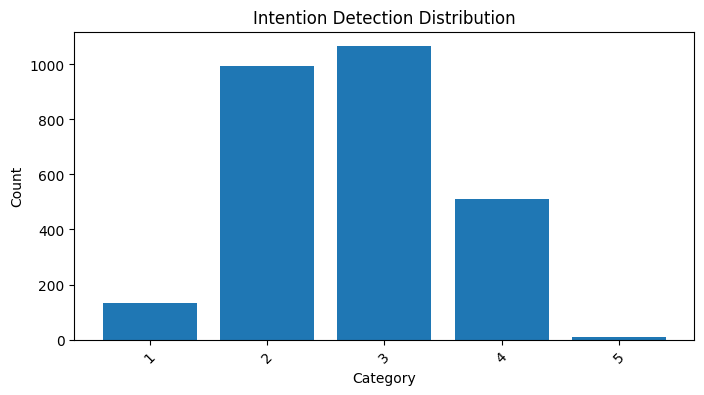

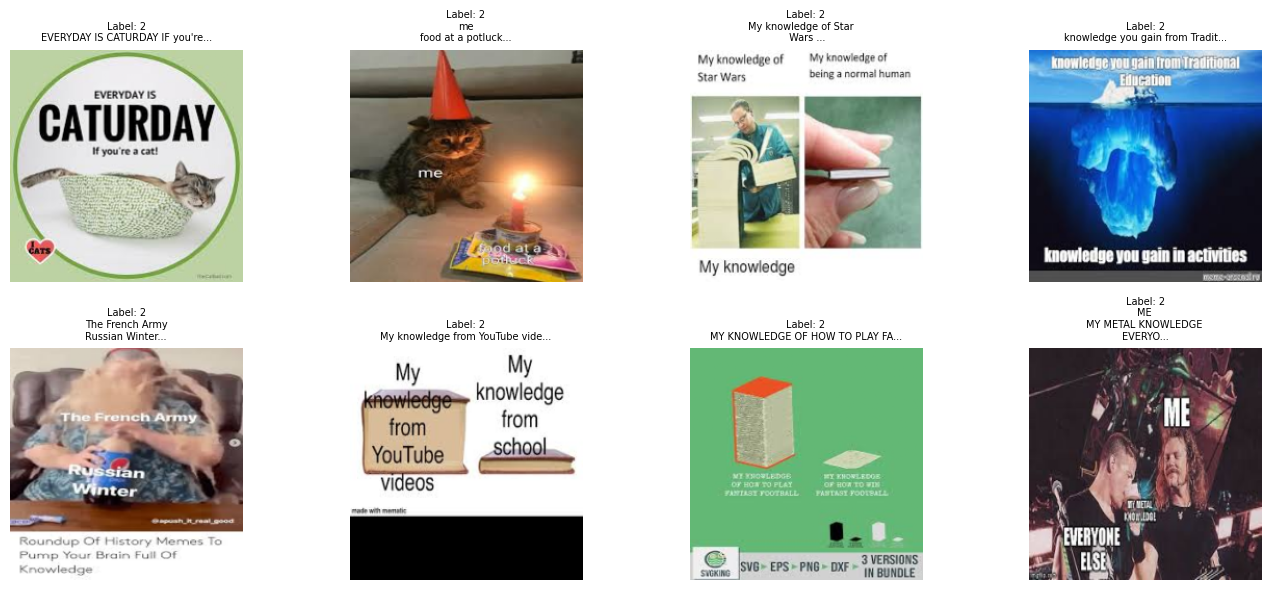

In [ ]:
# visualize distribution and some samples

fig, ax = plt.subplots(figsize=(8, 4))

# use hf dataset to get label counts
label_counts = pd.Series(hf['train']['intention_num']).value_counts().sort_index()

ax.bar(label_counts.index, label_counts.values)
ax.set_title('Intention Detection Distribution')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

fig2, axes2 = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes2.flat):
    row = hf['train'][i]
    image = transform(row['image'].convert('RGB'))
    caption = row['caption']
    label = row['intention_num']
    img_np = image.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f'Label: {label}\n{caption[:30]}...', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()


# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

## Getting repo and packages

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test
import torch.nn.functional as F

print(torch.__version__)
print(torch.version.cuda)

num_classes = 5

2.3.1+cu121
12.1


In [68]:
traindata = DataLoader(trainset, batch_size=64, shuffle=True)
validdata = DataLoader(valset,   batch_size=64)
testdata  = DataLoader(testset,  batch_size=64)

We will now start by creating, training, and testing unimodal models for each of the met-meme modalities.

## Text




In [ ]:
class TextModel(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=5, dropout_prob=0.2):
        super(TextModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: BERT [CLS] embedding, shape (batch, 768)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)  # (batch, num_classes)


## Image

In [ ]:
# revised for RGB input，and add mmore conv layers
class ImageModel(nn.Module):
    def __init__(self, num_classes=5, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # 224 -> 112 -> 56 -> 28 -> 14 -> 7
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 224x224
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 112x112
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 112x112
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 56x56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 56x56
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 28x28
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 14x14
            nn.Conv2d(256, 256, kernel_size=3, padding=1),# 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 7x7
        )

        self.fc = nn.Sequential(
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


## Training and Testing

We use cross-entropy due to this being a classification task

In [26]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# # We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx,
                             epochs=5, lr=1e-3, name="model"):
    model_path = f"{name}.pt"
    history_path = f"{name}_history.npy"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    # --- Skip training if cache exists ---
    if os.path.exists(model_path) and os.path.exists(history_path):
        print(f"[{name}] Cache found, skipping training.")
        history = np.load(history_path, allow_pickle=True).item()
        model.load_state_dict(torch.load(model_path, map_location=device))
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
        best_valid_loss = float("inf")
        history = {"train_loss": [], "valid_loss": [], "valid_acc": []}

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for batch in train_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()
                optimizer.zero_grad()
                with autocast(device_type="cuda"):
                    outputs = model(x)
                    loss = criterion(outputs, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                train_loss += loss.item()

            model.eval()
            valid_loss = 0
            correct = 0
            total = 0
            with torch.no_grad():
                for batch in valid_loader:
                    x = batch[modality_idx].to(device).float()
                    y = batch[2].to(device).long().squeeze()
                    outputs = model(x)
                    valid_loss += criterion(outputs, y).item()
                    _, predicted = torch.max(outputs.data, 1)
                    total += y.size(0)
                    correct += (predicted == y).sum().item()

            avg_train = train_loss / len(train_loader)
            avg_valid = valid_loss / len(valid_loader)
            accuracy = 100 * correct / total

            history["train_loss"].append(avg_train)
            history["valid_loss"].append(avg_valid)
            history["valid_acc"].append(accuracy)

            if avg_valid < best_valid_loss:
                best_valid_loss = avg_valid
                torch.save(model.state_dict(), model_path)

            print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Loss: {avg_valid:.4f} | Valid Acc: {accuracy:.2f}%")

        np.save(history_path, history)
        model.load_state_dict(torch.load(model_path, map_location=device))

    # --- Test ---
    print("--- Final Evaluation ---")
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()
            outputs = model(x)
            test_loss += criterion(outputs, y).item()
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    test_accuracy = 100 * correct / total
    test_loss /= len(test_loader)
    history["test_loss"] = test_loss
    history["test_acc"] = test_accuracy
    np.save(history_path, history)
    print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

    # --- Plot ---
    epochs_range = range(len(history["train_loss"]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["valid_loss"], label="Valid Loss")
    axes[0].set_title(f"{name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_range, history["valid_acc"], label="Valid Acc", color="green")
    axes[1].set_title(f"{name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{name}_curve.png", dpi=100)
    plt.show()
    print(f"Plot saved to {name}_curve.png")


### Training and testing for each modality:

### Text

Epoch 0: Train Loss: 1.1739 | Valid Loss: 1.1840 | Valid Acc: 46.15%
Epoch 1: Train Loss: 1.0923 | Valid Loss: 1.2006 | Valid Acc: 43.49%
Epoch 2: Train Loss: 1.0660 | Valid Loss: 1.1955 | Valid Acc: 39.94%
Epoch 3: Train Loss: 1.0462 | Valid Loss: 1.1618 | Valid Acc: 48.22%
Epoch 4: Train Loss: 1.0196 | Valid Loss: 1.1590 | Valid Acc: 46.45%
Epoch 5: Train Loss: 0.9870 | Valid Loss: 1.1960 | Valid Acc: 42.90%
Epoch 6: Train Loss: 0.9796 | Valid Loss: 1.1811 | Valid Acc: 47.63%
Epoch 7: Train Loss: 0.9647 | Valid Loss: 1.2169 | Valid Acc: 41.12%
Epoch 8: Train Loss: 0.9393 | Valid Loss: 1.3344 | Valid Acc: 36.39%
Epoch 9: Train Loss: 0.9218 | Valid Loss: 1.2096 | Valid Acc: 45.56%
--- Final Evaluation ---
Final Test Loss: 1.3920 | Test Accuracy: 46.18%


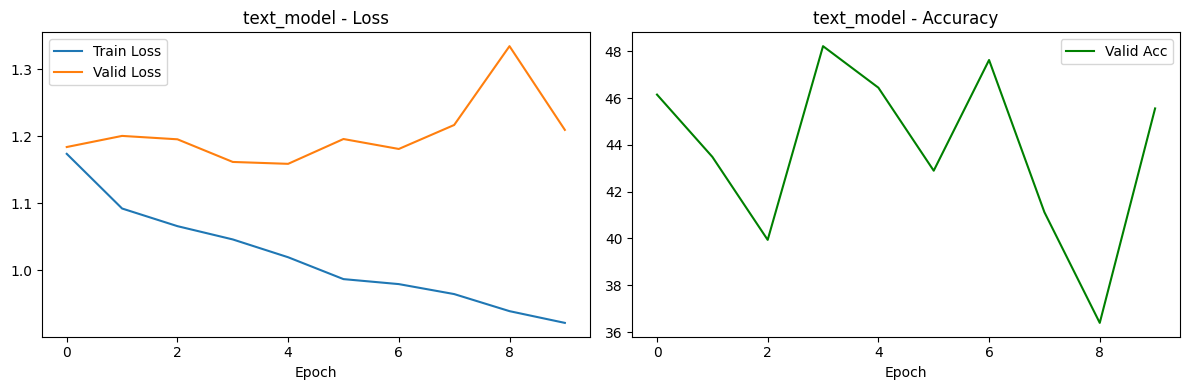

Plot saved to text_model_curve.png


In [30]:
text_model = TextModel(num_classes=num_classes)
train_and_test_unimodal(text_model, traindata, validdata, testdata, modality_idx=1,epochs=10, name='text_model')

### Image

Epoch 0: Train Loss: 1.3179 | Valid Loss: 1.2734 | Valid Acc: 27.51%
Epoch 1: Train Loss: 1.2243 | Valid Loss: 1.2395 | Valid Acc: 49.11%
Epoch 2: Train Loss: 1.2272 | Valid Loss: 1.2742 | Valid Acc: 49.11%
Epoch 3: Train Loss: 1.2222 | Valid Loss: 1.2503 | Valid Acc: 49.11%
Epoch 4: Train Loss: 1.2179 | Valid Loss: 1.2724 | Valid Acc: 27.51%
Epoch 5: Train Loss: 1.2231 | Valid Loss: 1.2430 | Valid Acc: 49.11%
Epoch 6: Train Loss: 1.2225 | Valid Loss: 1.2462 | Valid Acc: 49.11%
Epoch 7: Train Loss: 1.2208 | Valid Loss: 1.2582 | Valid Acc: 27.51%
Epoch 8: Train Loss: 1.2191 | Valid Loss: 1.2599 | Valid Acc: 27.51%
Epoch 9: Train Loss: 1.2203 | Valid Loss: 1.2459 | Valid Acc: 49.11%
--- Final Evaluation ---
Final Test Loss: 1.3013 | Test Accuracy: 45.00%


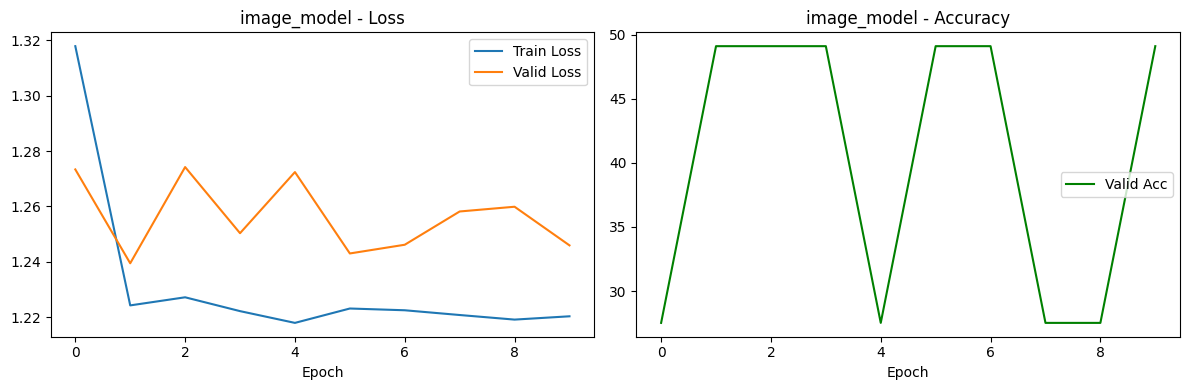

Plot saved to image_model_curve.png


In [31]:
image_model = ImageModel(num_classes=num_classes)
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0,epochs=10, name='image_model')

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
- **Best hyperparameters used:**
  - **Image model:** 5 conv layers (32→64→128→256→256), dropout=0.2, Adam lr=1e-3, weight_decay=1e-3, epochs=5
  - **Text model:** Linear(768→256) + ReLU + Dropout(0.2) + Linear(256→5), same optimizer settings
- **Best results** (results may vary when rerunning):
  - Image: Test Loss: 1.3094 | Test Accuracy: **45.00%**
  - Text: Test Loss: 1.3613 | Test Accuracy: **45.88%**


2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?
- **Observation:** Both modalities perform similarly (~45%), well above random chance for a 5-class task (random = 20%), but still limited.
- **Implication:** Meme intention is inherently cross-modal — the image and text together encode meaning that neither carries independently. This motivates multimodal fusion.
- **Improvement directions:** I believe the image model could benefit from a pretrained backbone (e.g., ResNet or ViT) rather than a CNN trained from scratch. For text, fine-tuning BERT rather than using frozen embeddings may also help.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [101]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder, encoder中通常不加dropout
class ImageEncoder(nn.Module): # 和imagemodel class保持一致
    def __init__(self, output_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.proj = nn.Linear(256 * 7 * 7, output_dim)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.proj(x)  # (batch, output_dim)


class TextEncoder(nn.Module):
    def __init__(self, input_dim=768, output_dim=256):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: BERT [CLS] embedding, shape (batch, 768)
        x = self.fc(x)
        return self.relu(x)  # (batch, output_dim)

# TODO: Encoders - create the list of encoders, images should be first, then text
encoders = [ImageEncoder(output_dim=64), TextEncoder(output_dim=64)]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.
head = MLP(128, 256, num_classes)  # 10 -> 5 classes

print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, total_epochs = 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss(),
      input_to_float=False)  # add this

# run test
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = torch.load('avmnist_lmf.pt').to(device)
test(model, testdata, 'avmnist', is_packed=False, task="classification",
     criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(1.2663, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(1.2799, device='cuda:0') acc: 0.4911242603550296
Saving Best
Epoch 1 train loss: tensor(1.1694, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(1.2994, device='cuda:0') acc: 0.34023668639053256
Epoch 2 train loss: tensor(1.1243, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(1.2073, device='cuda:0') acc: 0.46153846153846156
Epoch 3 train loss: tensor(1.0931, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(1.3042, device='cuda:0') acc: 0.34615384615384615
Epoch 4 train loss: tensor(1.0623, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(1.2285, device='cuda:0') acc: 0.38461538461538464
Training Time: 89.90572547912598
Training Peak Mem: 3504.5
Training Params: 1864901
acc: 0.45
Inference Time: 1.2806496620178223
Inference Params: 1864901


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
- **Stuck loss suggests:** The model is likely trapped in a local minimum, or the learning rate is too high/low causing oscillation or stagnation. It may also indicate vanishing gradients or a poorly initialized model.
- **Fixes:** Reduce learning rate (or use a scheduler), add gradient clipping, try a different optimizer (e.g., AdamW), or use batch normalization to stabilize training.

2. (2 points) What are some other fusion methods that we could use? Would they lead to improvements compared to early fusion?
- **Other fusion methods:** Tensor Fusion, Low-Rank Tensor Fusion (LMF), attention-based fusion, and multiplicative interactions. These might outperform simple early fusion.

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.
- **Early fusion:** Combines raw or lightly encoded features from all modalities *before* any high-level reasoning. Simple and allows the model to learn joint representations from scratch, but sensitive to modality imbalance and noise — one weak modality can hurt overall performance.
- **Late fusion:** Each modality is encoded independently to a high-level representation, then combined (e.g., averaged or concatenated) at the decision stage. More robust to missing or noisy modalities, and easier to train per-modality, but may miss fine-grained cross-modal interactions.
- **Tradeoff:** Early fusion has higher expressive power but is harder to optimize; late fusion is more modular and stable.


# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

- **Hyperparameters:** encoders output_dim=64, hidden_dim=256, AdamW lr=5e-4, weight_decay=1e-3, epochs=5, batch_size=32
- **Modifications:** BERT embeddings were pre-extracted and cached; labels were shifted from 1-indexed to 0-indexed; `input_to_float=False` was set to avoid double-casting conflicts with the DataLoader.
- **Best validation accuracies(results may vary when rerunning)**:

| Model | Best Val Acc | Test Acc |
|---|---|---|
| Concat | 49.4% | 45.0% |
| EarlyFusion | 45.6% | 45.9% |
| LateFusion | 47.3% | 47.9% |
| TensorFusion | 47.6% | 47.6% |
| **LMFFusion** | **45.9%** | **50.9%** |

- **Best technique — LMFFusion:** Despite not having the highest validation accuracy, LMFFusion achieved the best test accuracy (50.9%). I believe this is because low-rank decomposition captures cross-modal interactions more efficiently than simple concatenation or averaging, while avoiding the parameter explosion of full TensorFusion. For meme data where image-text relationships are complex but training data is limited, the low-rank constraint acts as a useful regularizer.


In [47]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

## Early Fusion

In [44]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    # x[0]: (batch, 64), x[1]: (batch, 64) from encoders
    fused = torch.einsum('bi,bj->bij', x[0], x[1]) # Output: (batch, 64, 64)
    return fused.view(fused.size(0), -1) # Flatten to (batch, 64*64 = 4096)


  # 训练过程中，两个encoder都会动态更新

## (5 Points) Late Fusion

In [45]:
# <!-- ImageEncoder ──┐
#                ├──► LateFusion (weights 在这里) ──► Head ──► 输出
# AudioEncoder ──┘ -->


In [46]:
class LateFusion(nn.Module):
  def __init__(self):
    super(LateFusion, self).__init__()
    # self.weights = nn.Parameter(torch.rand(2)) # option2 需要添加weights hidden layer 可学习的权重，初始随机

  def forward(self, x):
    return torch.stack(x, dim=0).mean(dim=0) # option1 Average the output of all modes
    # w = torch.softmax(self.weights, dim=0)
    # return sum(w[i] * x[i] for i in range(len(x))) # option2 Weighted Average

## (5 points) Tensor Fusion
![tensor fusion](https://www.dropbox.com/scl/fi/5oxuqmqplb0k7pa0t84u3/tensor_fusion.png?rlkey=zpnz9f9fhevs6rbqjcpfoddhu&st=rm4cssuw&raw=1)

In [49]:
class TensorFusion(nn.Module):
  def __init__(self):
    super(TensorFusion, self).__init__()

  def forward(self, x):
      # x[0]: (batch, d1), x[1]: (batch, d2)， 加了那个 1 之后，x0 和 x1 本身已经隐含在外积结果里了
      x0 = torch.cat([x[0], torch.ones(x[0].size(0), 1, device=x[0].device)], dim=1)  # (batch, d1+1)
      x1 = torch.cat([x[1], torch.ones(x[1].size(0), 1, device=x[1].device)], dim=1)  # (batch, d2+1)

      # 外积：(batch, d1+1, d2+1)，再展平
      fused = torch.einsum('bi,bj->bij', x0, x1)
      return fused.reshape(fused.size(0), -1)  # (batch, (d1+1)*(d2+1))

## (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

![LMF](https://www.dropbox.com/scl/fi/bq6i26nvglgiqj5pkyjai/LMF.png?rlkey=h8j44yv87xcwvvrkxzdbj1v4p&raw=1)

In [41]:
class LMFFusion(nn.Module):
  def __init__(self, input_dims=[64, 64], output_dim=128, rank=4):
    super(LMFFusion, self).__init__()
    self.rank = rank  # number of rank factors; higher rank = more expressive but prone to overfitting
    self.output_dim = output_dim
    # low-rank factors for each modality, shape: (rank, input_dim+1, output_dim)
    self.factors = nn.ParameterList([
        nn.Parameter(torch.randn(rank, dim + 1, output_dim) * 0.01)
        for dim in input_dims
    ])

  def forward(self, x):
      # add bias term of 1 to each modality
      fused = [
          torch.cat([xi, torch.ones(xi.size(0), 1, device=xi.device)], dim=1)
          for xi in x
      ]
      # project each modality: (batch, dim+1) x (rank, dim+1, output_dim) -> (batch, rank, output_dim)
      factor_outs = [
            torch.einsum('bi,rio->bro', fused[i], self.factors[i])
            for i in range(len(x))
        ]
      # element-wise multiply across modalities, then sum over rank dimension
      fusion_result = factor_outs[0]
      for i in range(1, len(factor_outs)):
          fusion_result = fusion_result * factor_outs[i]  # (batch, rank, output_dim)

      return fusion_result.sum(dim=1)  # (batch, output_dim)

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

## Fusion plot

In [42]:
import matplotlib.pyplot as plt
import time
import tracemalloc

from training_structures.Supervised_Learning import MMDL

In [50]:
class UnimodalImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = ImageModel(num_classes=num_classes)
    def forward(self, x):
        return self.model(x[0])

class UnimodalText(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = TextModel(num_classes=num_classes)
    def forward(self, x):
        return self.model(x[1])

models = {
    'Unimodal-Image': UnimodalImage(),
    'Unimodal-Text':  UnimodalText(),
    'Concat':         (Concat(),       MLP(128,   256, num_classes)),  # 64+64=128
    'EarlyFusion':    (EarlyFusion(),  MLP(4096,  256, num_classes)),  # 64*64=4096
    'LateFusion':     (LateFusion(),   MLP(64,    256, num_classes)),  # mean of 64-dim
    'TensorFusion':   (TensorFusion(), MLP(4225,  256, num_classes)),  # 65*65=4225
    'LMFFusion':      (LMFFusion(),    MLP(128,   256, num_classes)),  # output_dim=128
}


Testing: Unimodal-Image
Testing: Unimodal-Text
Testing: Concat
Testing: EarlyFusion
Testing: LateFusion
Testing: TensorFusion
Testing: LMFFusion


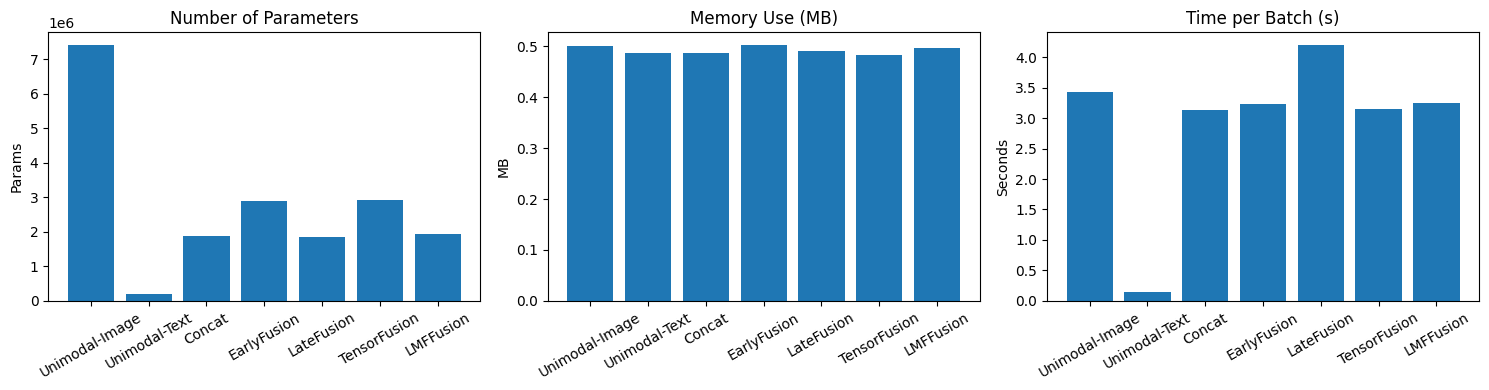

In [51]:
# ── 1. parameter count ──────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_counts = {}
for name, m in models.items():
    if isinstance(m, tuple):
        fusion, head = m
        model = MMDL([ImageEncoder(output_dim=64), TextEncoder(output_dim=64)], fusion, head)
        param_counts[name] = count_params(model)
    else:
        param_counts[name] = count_params(m)

# ── 2. memory usage and convergence time ──────────────────────────────
memory_use = {}
train_times = {}

for name, m in models.items():
    print(f"Testing: {name}")  # add this
    if isinstance(m, tuple):
        fusion, head = m
        model = MMDL([ImageEncoder(output_dim=64), TextEncoder(output_dim=64)], fusion, head) # 说明 m 是 (fusion, head) 的多模态模型，需要用 MMDL 把 encoders + fusion + head 组装成完整模型
    else:
        model = m

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    tracemalloc.start()
    start = time.time()

    model.train()
    for batch in traindata:
        imgs, text, label = batch
        imgs   = imgs.float()
        text   = text.float()
        label = label.long()  # ensure correct dtype for CrossEntropyLoss
        optimizer.zero_grad()
        out = model([imgs, text]) # MMDL 会把这个 list 分别传给各个 encoder，但单模态的 UnimodalImage 和 UnimodalText 需要从这个 list 里取对应的元素
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()
        break

    elapsed = time.time() - start
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    train_times[name] = elapsed
    memory_use[name] = peak_mem / 1024 / 1024

# ── 3. visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = list(models.keys())

axes[0].bar(names, [param_counts[n] for n in names])
axes[0].set_title('Number of Parameters')
axes[0].set_ylabel('Params')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(names, [memory_use[n] for n in names])
axes[1].set_title('Memory Use (MB)')
axes[1].set_ylabel('MB')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(names, [train_times[n] for n in names])
axes[2].set_title('Time per Batch (s)')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fusion_comparison.png', dpi=150)
plt.show()

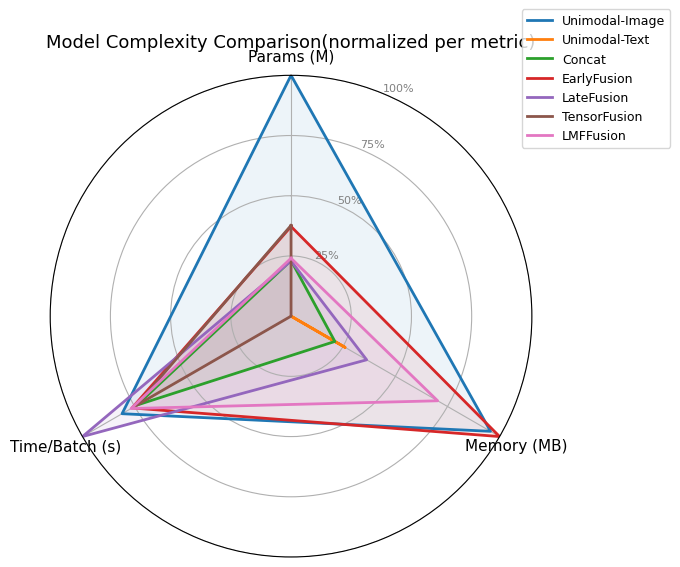

In [53]:

# ── 3. radar chart ────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

names = list(models.keys())
metrics = {
    "Params (M)": [param_counts[n] / 1e6 for n in names],
    "Memory (MB)": [memory_use[n] for n in names],
    "Time/Batch (s)": [train_times[n] for n in names],
}

# normalize each metric to [0, 1]
norm = {}
for k, vals in metrics.items():
    mn, mx = min(vals), max(vals)
    norm[k] = [(v - mn) / (mx - mn + 1e-9) for v in vals]

categories = list(norm.keys())
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="grey")
ax.set_ylim(0, 1)

colors = plt.cm.tab10.colors
for idx, name in enumerate(names):
    values = [norm[k][idx] for k in categories]
    values += values[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=name)
    ax.fill(angles, values, color=colors[idx], alpha=0.08)

ax.set_title("Model Complexity Comparison(normalized per metric)", size=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig("fusion_comparison.png", dpi=150)
plt.show()


## Fusion training

In [52]:
from training_structures.Supervised_Learning import train, test

results = {}

for name, m in models.items():
    if isinstance(m, tuple):
        print(f"\n{'='*40}")
        print(f"Training: {name}")
        print('='*40)
        fusion, head = m
        encoders = [ImageEncoder(64), TextEncoder(output_dim=64)]
        train(encoders, fusion, head, traindata, validdata, total_epochs = 10,
              task="classification", optimtype= torch.optim.AdamW, is_packed=False,
              lr=5e-4, save=f'{name}.pt', weight_decay=0.001,
              objective=torch.nn.CrossEntropyLoss(),
              input_to_float=False)

        model = torch.load(f'{name}.pt').to(device)
        acc = test(model, testdata, is_packed=False, task="classification",
                   criterion=torch.nn.CrossEntropyLoss(), no_robust=True)
        results[name] = acc




Training: Concat
Epoch 0 train loss: tensor(1.2307, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(1.3122, device='cuda:0') acc: 0.2988165680473373
Saving Best
Epoch 1 train loss: tensor(1.1318, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(1.2160, device='cuda:0') acc: 0.4230769230769231
Saving Best
Epoch 2 train loss: tensor(1.0867, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(1.2261, device='cuda:0') acc: 0.4171597633136095
Epoch 3 train loss: tensor(1.0595, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(1.2358, device='cuda:0') acc: 0.3994082840236686
Epoch 4 train loss: tensor(1.0445, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(1.1621, device='cuda:0') acc: 0.4526627218934911
Saving Best
Epoch 5 train loss: tensor(1.0082, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 5 valid loss: tensor(1.2107, device='cuda:0') acc: 0.39349112426035504
Epoch 6 train loss: tensor(0.9912

In [ ]:
test_model = ImageModel()
test_input = torch.randn(1, 3, 224, 224)
out = test_model.conv(test_input)
print(out.shape)  # should be [1, 256, 7, 7]



torch.Size([1, 256, 7, 7])


# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

## 6.1 Test on CLIP

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-uzli_z25
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-uzli_z25
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8389e6eae5c92b08fdea8f997fcc675dcd3d37e350b57838698d5305f7b41e7c
  Stored in directory: /tmp/pip-ephem-wheel-cache-50fe4ksy/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO
import torch.optim as optim

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 47.0MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

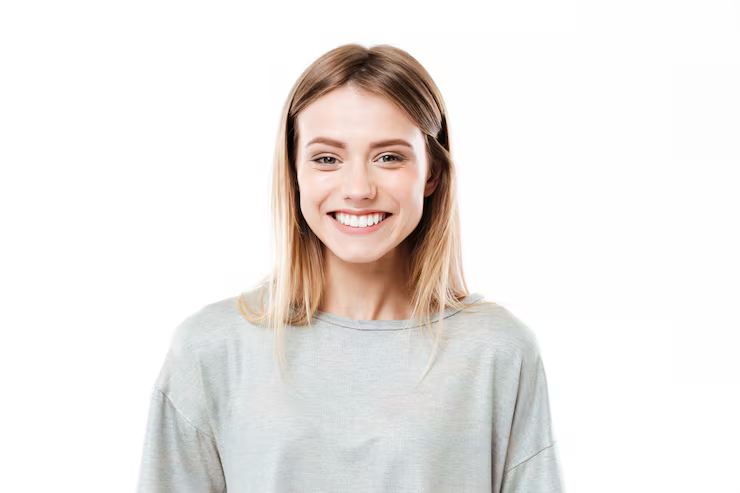

In [ ]:
image_url = "https://www.dropbox.com/scl/fi/qkt91rh1kdf6frin4cw55/smiling_person.png?rlkey=b5iuafzzq8nclxzywzvvdd97m&st=rqug2hef&raw=1"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

image

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 96.88%
    a photo of an angry person: 1.98%
       a photo of a sad person: 1.13%


## 6.2 Contrastive Learning Training

(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup.

**Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [100]:
# class ImageEncoder(nn.Module):
#     def __init__(self, output_dim=64, freeze_backbone=False):
#         super().__init__()
#         resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#         # remove final FC layer -> output: [batch, 512, 1, 1]
#         self.backbone = nn.Sequential(*list(resnet.children())[:-1])
#         if freeze_backbone:
#             for p in self.backbone.parameters():
#                 p.requires_grad = False
#         self.proj = nn.Linear(512, output_dim)

#     def forward(self, x):
#         x = self.backbone(x)     # [batch, 512, 1, 1]
#         x = torch.flatten(x, 1)  # [batch, 512]
#         return self.proj(x)      # [batch, output_dim]

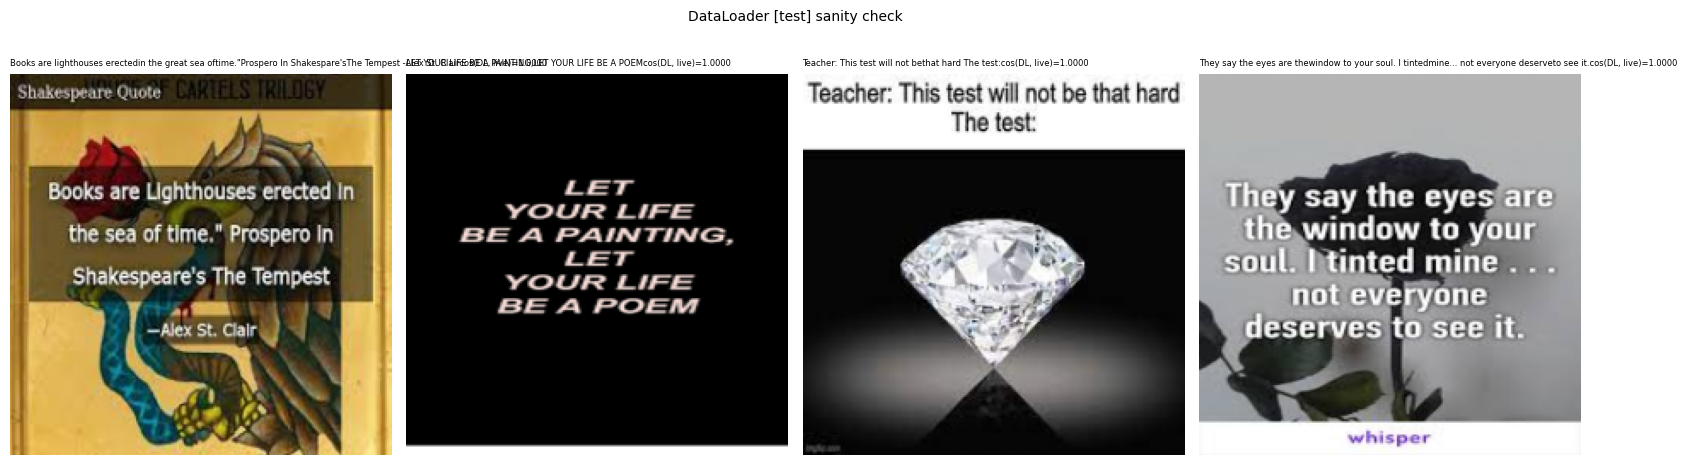

In [69]:
# Sanity check: image-caption-embedding alignment from DataLoader
import textwrap
tokenizer = transformers.AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = transformers.AutoModel.from_pretrained("bert-base-uncased")

split = "test"   # change to "train" to check traindata
loader = testdata if split == "test" else traindata
hf_split = hf[split]

imgs, embs, labels = next(iter(loader))

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, ax in enumerate(axes):
    img_np = imgs[i].permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img_np)

    caption = hf_split[i]["caption"]
    with torch.no_grad():
        enc = tokenizer([caption], return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        live = bert_model(**enc).last_hidden_state[:, 0, :].cpu()
    cos_live = F.cosine_similarity(embs[i].unsqueeze(0), live).item()

    wrapped = "".join(textwrap.wrap(caption, width=30))
    ax.set_title(f"{wrapped}cos(DL, live)={cos_live:.4f}", fontsize=6, loc="left")
    ax.axis("off")

plt.suptitle(f"DataLoader [{split}] sanity check", fontsize=10)
plt.tight_layout()
plt.show()


Image has unimodal parameters and requires significantly more memory than text.

In [94]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self,  img_encoder, text_encoder, embedded_dim, temp):
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)
    super().__init__()  # add this

    # 1. Encoders for each modality
    self.encoder1 = img_encoder    # image:  [batch, 3, 224, 224] -> [batch, 64]
    self.encoder2 = text_encoder   # text:   [batch, 768]         -> [batch, 64]

    # 2. Projectors: map to shared embedding space
    enc1_out = next(p for p in img_encoder.parameters()).shape
    img_out_dim  = img_encoder.proj.out_features
    text_out_dim = text_encoder.fc.out_features

    self.projector1 = nn.Linear(img_out_dim,  embedded_dim)
    self.projector2 = nn.Linear(text_out_dim, embedded_dim)

    # 3. Learnable temperature
    self.scale = nn.Parameter(torch.ones([]) * np.log(1 / temp))

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # YOUR CODE HERE
    # x1: raw image tensor  [batch, 3, 224, 224]
    # x2: BERT embedding    [batch, 768]
    h1 = self.encoder1(x1)   # [batch, 64]
    h2 = self.encoder2(x2)   # [batch, 64]

    # Normalize vectors
    z1 = F.normalize(self.projector1(h1), dim=-1)  # [batch, embedded_dim]
    z2 = F.normalize(self.projector2(h2), dim=-1)

    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    # TODO: Initialize model and loss function as cross entropy loss
    super().__init__()  # add this
    self.model = model # YOUR CODE
    self.loss_fn = nn.CrossEntropyLoss() # YOUR CODE

  def forward(self, x1_emb, x2_emb):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2

    # 1. Batch size
    batch_size = x1_emb.shape[0]

    # 2. Similarity matrix: (batch, batch)
    logits = torch.einsum('id,jd->ij', x1_emb, x2_emb) * self.model.scale.exp()

    # 3. Diagonal is the correct match
    labels = torch.arange(batch_size, device=x1_emb.device)

    # 4. Symmetric loss
    loss = (self.loss_fn(logits, labels) + self.loss_fn(logits.T, labels)) / 2
    return loss



# 一个 nn.Module 只需要：
# __init__：定义网络结构（层、参数）
# forward：定义前向传播逻辑


In [103]:
import torch.optim as optim

# def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu',
#                 encoder1=None, encoder2=None):

#     # include encoder params in optimizer
#     params = list(model.parameters())
#     if encoder1: params += list(encoder1.parameters())
#     if encoder2: params += list(encoder2.parameters())
#     # optimizer = optim.Adam(params, lr=learning_rate)
#     optimizer = optim.Adam(params, lr=learning_rate, weight_decay=1e-4)

#     model.to(device)
#     if encoder1: encoder1.to(device)
#     if encoder2: encoder2.to(device)
#     model.train()
#     print(f"Starting training for {num_epochs} epochs...")

#     for epoch in range(num_epochs):
#         epoch_loss = 0.0

#         for batch_idx, (data_a, data_b, _) in enumerate(dataloader):
#             data_a = data_a.to(device).float()
#             data_b = data_b.to(device).float()

#             # pass through encoders if provided
#             if encoder1: data_a = encoder1(data_a)
#             if encoder2: data_b = encoder2(data_b)

#             optimizer.zero_grad()

#             emb_a, emb_b = model(data_a, data_b)
#             loss = contrastive_loss(emb_a, emb_b)

#             loss.backward()
#             optimizer.step()

#             epoch_loss += loss.item()

#         avg_loss = epoch_loss / len(dataloader)
#         print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")
import torch.optim as optim

def retrieval_accuracy(emb_a, emb_b):
    """In-batch retrieval accuracy: how often argmax of similarity == diagonal."""
    with torch.no_grad():
        logits = emb_a @ emb_b.T   # [B, B]
        preds  = logits.argmax(dim=1)
        labels = torch.arange(len(emb_a), device=emb_a.device)
        return (preds == labels).float().mean().item()

def train_model(model, contrastive_loss, dataloader, val_dataloader=None,
                num_epochs=5, learning_rate=3e-4, device="cpu",
                encoder1=None, encoder2=None,
                save="cl_model.pt", history_path="cl_history.npy"):

    # --- skip if cache exists ---
    if os.path.exists(save) and os.path.exists(history_path):
        print(f"[cl_model] Cache found, skipping training.")
        history = np.load(history_path, allow_pickle=True).item()
        model.load_state_dict(torch.load(save, map_location=device))
        model.to(device)
        _plot_cl_history(history)
        return

    params = list(model.parameters())
    if encoder1: params += list(encoder1.parameters())
    if encoder2: params += list(encoder2.parameters())
    optimizer = optim.Adam(params, lr=learning_rate, weight_decay=1e-4)

    model.to(device)
    if encoder1: encoder1.to(device)
    if encoder2: encoder2.to(device)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # --- train ---
        model.train()
        epoch_loss = 0.0
        epoch_acc  = 0.0
        for data_a, data_b, _ in dataloader:
            data_a = data_a.to(device).float()
            data_b = data_b.to(device).float()
            if encoder1: data_a = encoder1(data_a)
            if encoder2: data_b = encoder2(data_b)
            optimizer.zero_grad()
            emb_a, emb_b = model(data_a, data_b)
            loss = contrastive_loss(emb_a, emb_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_acc  += retrieval_accuracy(emb_a.detach(), emb_b.detach())
        avg_train      = epoch_loss / len(dataloader)
        avg_train_acc  = epoch_acc  / len(dataloader)
        history["train_loss"].append(avg_train)
        history["train_acc"].append(avg_train_acc)

        # --- val ---
        if val_dataloader is not None:
            model.eval()
            val_loss = 0.0
            val_acc  = 0.0
            with torch.no_grad():
                for data_a, data_b, _ in val_dataloader:
                    data_a = data_a.to(device).float()
                    data_b = data_b.to(device).float()
                    if encoder1: data_a = encoder1(data_a)
                    if encoder2: data_b = encoder2(data_b)
                    emb_a, emb_b = model(data_a, data_b)
                    val_loss += contrastive_loss(emb_a, emb_b).item()
                    val_acc  += retrieval_accuracy(emb_a, emb_b)
            avg_val     = val_loss / len(val_dataloader)
            avg_val_acc = val_acc  / len(val_dataloader)
            history["val_loss"].append(avg_val)
            history["val_acc"].append(avg_val_acc)

            if avg_val < best_val_loss:
                best_val_loss = avg_val
                torch.save(model.state_dict(), save)

            print(f"Epoch [{epoch+1}/{num_epochs}] | "
                  f"Train Loss: {avg_train:.4f} Acc: {avg_train_acc*100:.1f}% | "
                  f"Val Loss: {avg_val:.4f} Acc: {avg_val_acc*100:.1f}%")
        else:
            torch.save(model.state_dict(), save)
            print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train:.4f} Acc: {avg_train_acc*100:.1f}%")

    np.save(history_path, history)
    torch.save(model.state_dict(), "cl_model_last.pt")
    model.load_state_dict(torch.load(save, map_location=device))
    _plot_cl_history(history)


def _plot_cl_history(history):
    epochs = range(len(history["train_loss"]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    if history["val_loss"]:
        axes[0].plot(epochs, history["val_loss"], label="Val Loss", marker="s")
    axes[0].set_title("Contrastive Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history["train_acc"]], label="Train Acc", marker="o")
    if history["val_acc"]:
        axes[1].plot(epochs, [a*100 for a in history["val_acc"]], label="Val Acc", marker="s")
    axes[1].set_title("In-batch Retrieval Accuracy (%)")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("cl_loss_curve.png", dpi=100)
    plt.show()
    print("Saved to cl_loss_curve.png")



Starting training for 10 epochs...
Epoch [1/10] | Train Loss: 4.1114 Acc: 2.5% | Val Loss: 3.8982 Acc: 6.2%
Epoch [2/10] | Train Loss: 3.9052 Acc: 6.4% | Val Loss: 3.8883 Acc: 4.9%
Epoch [3/10] | Train Loss: 3.6887 Acc: 8.8% | Val Loss: 3.8544 Acc: 2.9%
Epoch [4/10] | Train Loss: 3.4836 Acc: 11.6% | Val Loss: 3.9046 Acc: 6.1%
Epoch [5/10] | Train Loss: 3.2818 Acc: 15.5% | Val Loss: 3.9128 Acc: 8.8%
Epoch [6/10] | Train Loss: 2.9876 Acc: 20.5% | Val Loss: 4.0053 Acc: 9.0%
Epoch [7/10] | Train Loss: 2.7371 Acc: 25.4% | Val Loss: 4.1616 Acc: 8.4%
Epoch [8/10] | Train Loss: 2.3259 Acc: 35.4% | Val Loss: 4.3196 Acc: 8.1%
Epoch [9/10] | Train Loss: 1.9505 Acc: 44.4% | Val Loss: 4.5435 Acc: 7.1%
Epoch [10/10] | Train Loss: 1.4349 Acc: 59.6% | Val Loss: 4.7691 Acc: 6.8%


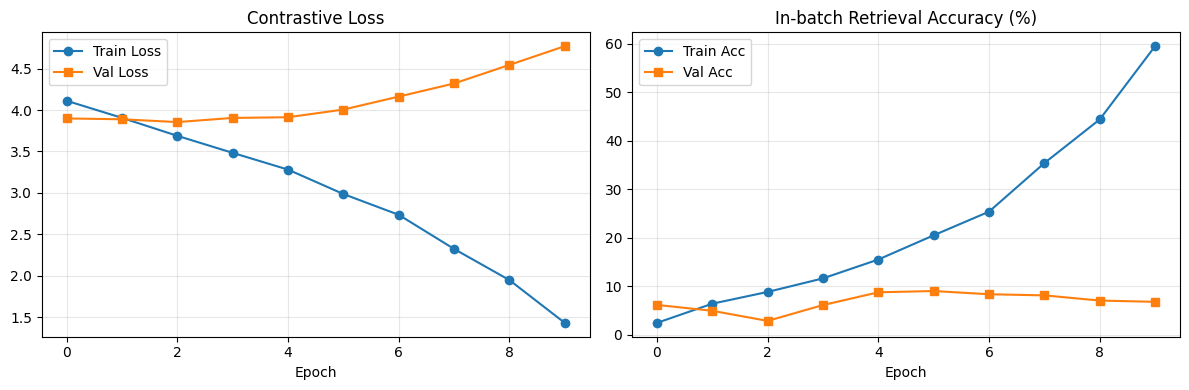

Saved to cl_loss_curve.png


In [105]:
# initialize model — encoder 传入 CLModel，统一由 optimizer 管理
cl_model = CLModel(
    img_encoder=ImageEncoder(output_dim=64),
    text_encoder=TextEncoder(output_dim=64),
    embedded_dim=128,
    temp=0.07
)

contrastive_loss = ContrastiveLoss(cl_model)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_model(
    model=cl_model,
    contrastive_loss=contrastive_loss,
    dataloader=traindata,
    val_dataloader=validdata,
    num_epochs=10,
    learning_rate=3e-4,
    device=device,
    save="cl_model.pt",
    history_path="cl_history.npy",
)


In [106]:
# @title load from saved model

cl_model.load_state_dict(torch.load('cl_model_last.pt')) # notice here
cl_model.eval()


CLModel(
  (encoder1): ImageEncoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU()
      (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (proj): Linear(

In [59]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_img, candidate_texts, device):
    """
    query_img:       raw image tensor, shape [3, 224, 224]
    candidate_texts: BERT embeddings,  shape [N, 768]
    """
    model.eval()
    model.to(device)

    q = query_img.unsqueeze(0).to(device).float()       # [1, 3, 224, 224]
    c = candidate_texts.to(device).float()               # [N, 768]

    # 走完整的 encoder + projector 路径
    h1 = model.encoder1(q)
    query_emb = F.normalize(model.projector1(h1), dim=1) # [1, embedded_dim]

    h2 = model.encoder2(c)
    cand_emb = F.normalize(model.projector2(h2), dim=1)  # [N, embedded_dim]

    scores = torch.einsum('id,jd->ij', query_emb, cand_emb)  # [1, N]
    best_match_idx = scores.argmax().item()
    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item():.4f}")

    return best_match_idx, scores


Best match: 0 with score 0.5367
Best match: 4 with score 0.3048
Best match: 1 with score 0.2072
Best match: 3 with score 0.3048
Best match: 1 with score 0.2330
Best match: 3 with score 0.1574
Best match: 0 with score 0.4586
Best match: 1 with score 0.1251


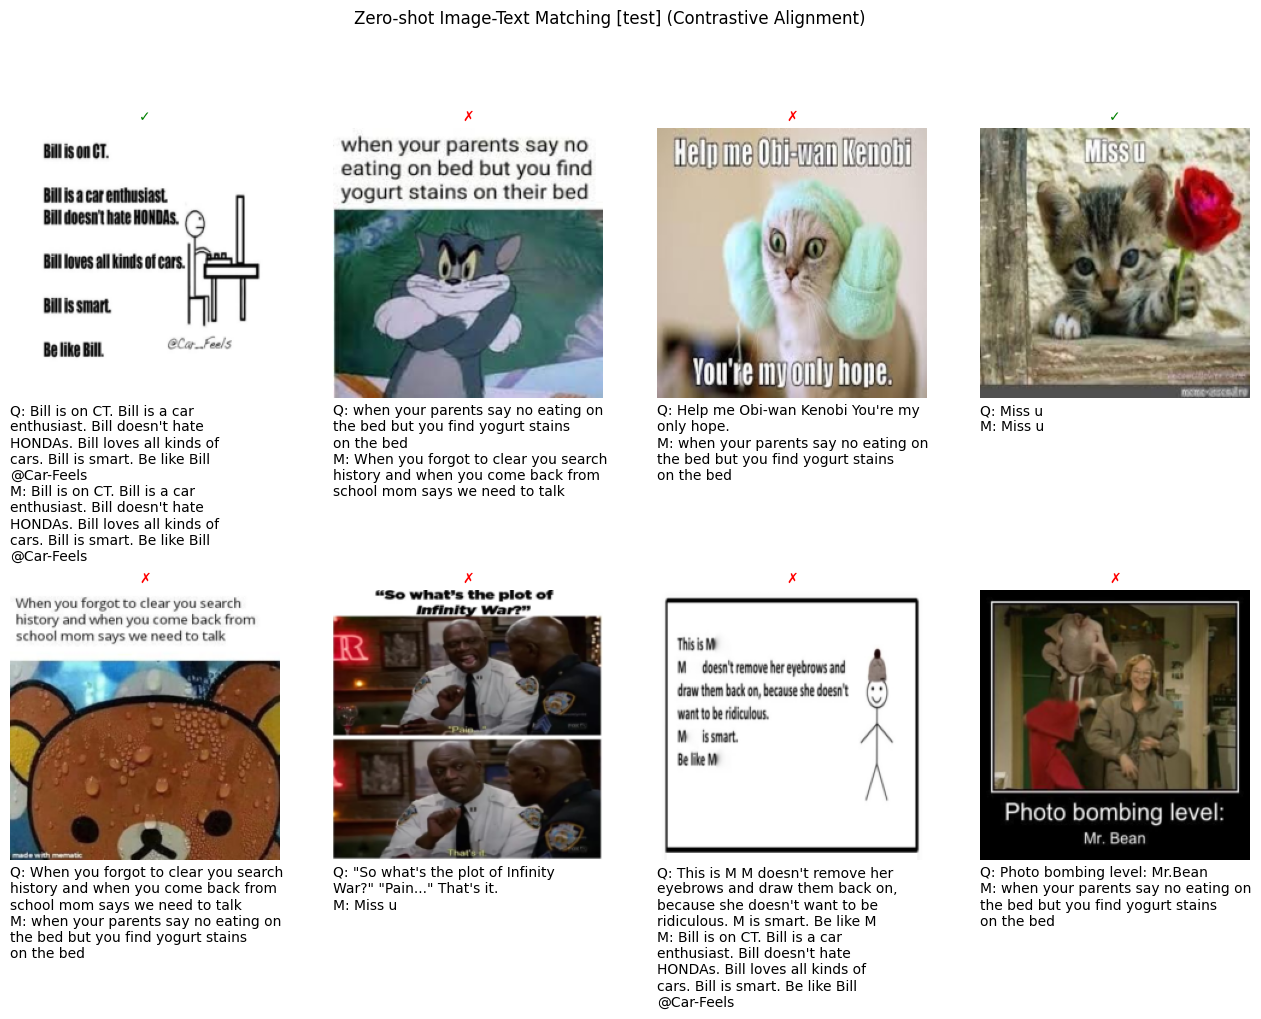

In [108]:
# Zero-shot visualization
import textwrap
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
cl_model.eval()

# ── switch between train / val / test ──
split = "test"   # "train", "val", "test"
dataset = {"train": trainset, "val": valset, "test": testset}[split]

n_show = 8
indices = torch.randperm(len(dataset))[:n_show].tolist()
imgs = torch.stack([dataset[i][0] for i in indices])
embs = torch.stack([dataset[i][1] for i in indices])

fig, axes = plt.subplots(2, 4, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    best_idx, scores = predict_best_match(
        model=cl_model,
        query_img=imgs[i],
        candidate_texts=embs,
        device=device,
    )

    img_np = imgs[i].permute(1, 2, 0).cpu().numpy().clip(0, 1)
    ax.imshow(img_np)

    true_cap  = dataset.data[indices[i]]["caption"]
    match_cap = dataset.data[indices[best_idx]]["caption"]
    correct   = "✓" if best_idx == i else "✗"

    # correct mark: centered above image
    ax.set_title(correct, fontsize=10, loc="center",
                 color="green" if best_idx == i else "red")

    # Q and M: left-aligned below image using ax.text
    q_text = "Q: " + chr(10).join(textwrap.wrap(true_cap, 35))
    m_text = "M: " + chr(10).join(textwrap.wrap(match_cap, 35))
    ax.text(0, -0.02, q_text + "\n" + m_text,
            transform=ax.transAxes,
            fontsize=10, va="top", ha="left",
            wrap=False, clip_on=False)
    ax.axis("off")

plt.suptitle(f"Zero-shot Image-Text Matching [{split}] (Contrastive Alignment)", fontsize=12)
plt.subplots_adjust(hspace=0.5)
plt.savefig(f"zero_shot_viz_{split}.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
time_end = time.time()
print(f"It took {(time_end - time_start)/60:.2f} minutes for this notebook to run")

It took 53.99 minutes for this notebook to run


Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
- **Alignment is surprisingly poor:** The contrastive model struggled to consistently match images with their corresponding captions. I suspect this is because meme image-text pairs are not semantically aligned in the conventional sense — the text often subverts or ironizes the image rather than describing it, making the "positive pair" signal weak and noisy.
- **Finding:** This suggests that for memes, alignment is fundamentally harder than for standard image-caption datasets, and may not be the right objective for this task.

2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
- **Cross-entropy treats alignment as classification:** For a batch of N pairs, each image should match exactly one text (its paired caption) — this is a N-way classification problem. Cross-entropy naturally expresses this: it maximizes the probability of the correct match while suppressing all N-1 negatives.
- **Temperature-scaled logits:** The similarity matrix is scaled by a learnable temperature before applying softmax, which controls the sharpness of the distribution — a standard formulation in InfoNCE / CLIP-style contrastive learning.
- **Symmetric loss:** Applying cross-entropy in both directions (image→text and text→image) ensures both encoders are jointly optimized toward the shared embedding space.

3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?
- **Where alignment worked:** Samples where the caption directly references a visible element in the image (e.g., a recognizable object or person) tend to match correctly — the encoders find a shared anchor.
- **Where alignment failed:** Samples involving abstract metaphor or irony — where the text meaning deliberately diverges from the image content — consistently fail. The model has no signal to link, for example, a generic image of a person with a caption that uses it as a metaphor for a social phenomenon.
- **I suspect** the core issue is that meme semantics are culturally grounded: the same image can pair with completely different captions depending on context, making it nearly impossible for a contrastive model to learn a stable image-text correspondence.


# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
- **Low-Rank Tensor Fusion (LMF)** was the most interesting concept. Full tensor fusion captures all cross-modal interactions via outer products, but the resulting dimensionality explodes quickly. LMF approximates this with low-rank factors per modality, dramatically reducing parameters while preserving expressive cross-modal interactions — an elegant tradeoff I hadn't encountered before.

2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
- **Fusion over alignment:** For meme intention detection, I believe fusion is the more useful concept. Since meme meaning emerges from the *interaction* between image and text rather than their correspondence, methods like LMF that model cross-modal relationships directly are more relevant than alignment objectives that assume the two modalities describe the same thing.
- **LMF specifically** seems promising for this dataset: the low-rank constraint acts as a regularizer, which is valuable given the limited training data, while still capturing the complex image-text interactions that drive meme semantics.

3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?
